In [1]:
!pip install torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.functional as TF
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from torchvision.datasets import OxfordIIITPet

In [2]:
IMAGE_SIZE = 128
BATCH_SIZE = 8

transform_img = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

transform_mask = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.PILToTensor(),
])

class PetDataset(Dataset):
    def __init__(self, root, split="trainval"):
        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]

        img = transform_img(img)
        mask = transform_mask(mask).squeeze(0)

        mask = (mask == 1).float()

        return img, mask.unsqueeze(0)

In [3]:
train_dataset = PetDataset(root="data", split="trainval")
test_dataset = PetDataset(root="data", split="test")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

100%|██████████| 792M/792M [00:30<00:00, 26.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.5MB/s]


In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))

        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [6]:
EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.5344
Epoch 2, Loss: 0.4800
Epoch 3, Loss: 0.4641
Epoch 4, Loss: 0.4559
Epoch 5, Loss: 0.4503
Epoch 6, Loss: 0.4326
Epoch 7, Loss: 0.4178
Epoch 8, Loss: 0.3804
Epoch 9, Loss: 0.3459
Epoch 10, Loss: 0.3173
Epoch 11, Loss: 0.2938
Epoch 12, Loss: 0.2797
Epoch 13, Loss: 0.2676
Epoch 14, Loss: 0.2581
Epoch 15, Loss: 0.2489


In [7]:
def iou_score(preds, masks):
    preds = torch.sigmoid(preds) > 0.5
    intersection = (preds & masks.bool()).float().sum()
    union = (preds | masks.bool()).float().sum()
    return (intersection / (union + 1e-8)).item()


def dice_score(preds, masks):
    preds = torch.sigmoid(preds) > 0.5
    intersection = (preds & masks.bool()).float().sum()
    return (2 * intersection / (preds.sum() + masks.sum() + 1e-8)).item()

In [8]:
model.eval()
iou_total = 0
dice_total = 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        iou_total += iou_score(preds, masks)
        dice_total += dice_score(preds, masks)

print("Mean IoU:", iou_total / len(test_loader))
print("Mean Dice:", dice_total / len(test_loader))

Mean IoU: 0.6810494738596456
Mean Dice: 0.8070159994698818


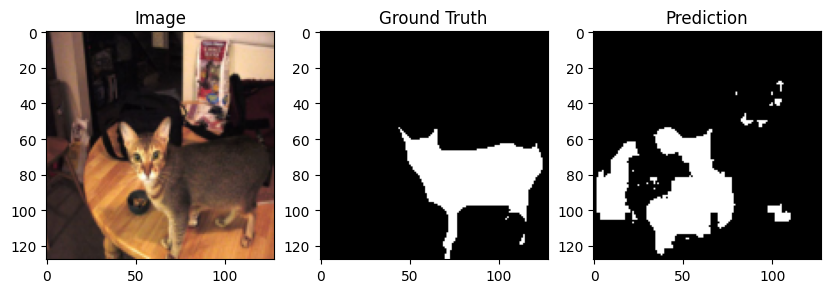

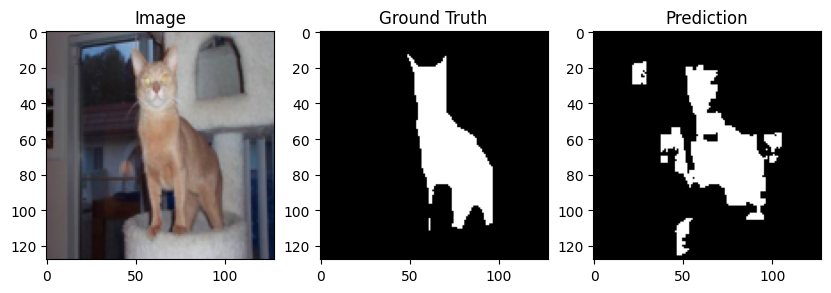

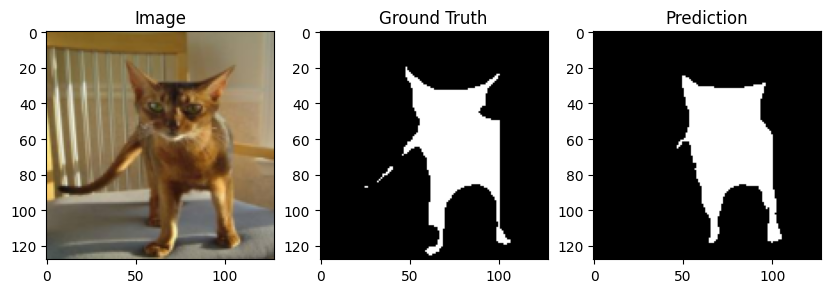

In [9]:
def show_predictions(model, loader):
    model.eval()
    images, masks = next(iter(loader))

    images = images.to(device)
    preds = torch.sigmoid(model(images)) > 0.5

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    for i in range(3):
        plt.figure(figsize=(10,3))

        plt.subplot(1,3,1)
        plt.imshow(images[i].permute(1,2,0))
        plt.title("Image")

        plt.subplot(1,3,2)
        plt.imshow(masks[i][0], cmap="gray")
        plt.title("Ground Truth")

        plt.subplot(1,3,3)
        plt.imshow(preds[i][0], cmap="gray")
        plt.title("Prediction")

        plt.show()

show_predictions(model, test_loader)

In [10]:
torch.save(model.state_dict(), "unet_pet.pth")